# 0. Import library

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


# 1-1. Import Data 

In [2]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


## 1-2. Normalize data

In [3]:
# stack input array
x_original_scale = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)
y_original_scale = np.concatenate((mp_temp, mp_depth), axis=1)

# scaling
x_max = np.max(x_original_scale,0).reshape(1,-1)
x_min = np.min(x_original_scale,0).reshape(1,-1) 
y_max = np.max(y_original_scale,0).reshape(1,-1) 
y_min = np.min(y_original_scale,0).reshape(1,-1)

print("x_max:", np.round(x_max, 3).tolist())
print("x_min:", np.round(x_min, 3).tolist())
print("y_max:", np.round(y_max, 3).tolist())
print("y_min:", np.round(y_min, 3).tolist())

x_max: [[7.5, 20.0, 20.0, 732.298]]
x_min: [[0.0, 0.75, 0.75, 504.26]]
y_max: [[4509.855, 0.551]]
y_min: [[436.608, -0.559]]


In [4]:
class scalers():
    def __init__(self, x_max, x_min, y_max, y_min) -> None:
        self.x_max = x_max; self.x_min = x_min
        self.y_max = y_max; self.y_min = y_min

    def scaler_x(self, x_original, dim_id=-1):
        if dim_id == -1:
            return -1 + 2 * ((x_original - self.x_min) / (self.x_max - self.x_min))
        else:
            return -1 + 2 * (x_original - self.x_min[0, dim_id]) / (self.x_max[0, dim_id] - self.x_min[0, dim_id])

    def inv_scaler_x(self, x_s, dim_id=-1):
        if dim_id == -1:
            return (x_s + 1) * 0.5 * (self.x_max - self.x_min) + self.x_min
        else:
            return (x_s + 1) * 0.5 * (self.x_max[0, dim_id] - self.x_min[0, dim_id]) + self.x_min[0, dim_id]

    def scaler_y(self, y_original):
        return -1 + 2 * ((y_original - self.y_min) / (self.y_max - self.y_min))

    def inv_scaler_y(self, y_s):
        return (y_s + 1) * 0.5 * (self.y_max - self.y_min) + self.y_min

In [5]:
scaler = scalers(x_max, x_min, y_max, y_min)

x_s, y_s = scaler.scaler_x(x_original_scale), scaler.scaler_y(y_original_scale)

print("x_s range:", np.min(x_s), "to", np.max(x_s))
print("y_s range:", np.min(y_s), "to", np.max(y_s))
print("x_s shape:", x_s.shape, "| y_s shape:", y_s.shape)

x_s range: -1.0 to 1.0
y_s range: -1.0 to 1.0
x_s shape: (610417, 4) | y_s shape: (610417, 2)


## 1-3. Generate data

In [6]:
length = y_s.shape[0]

y_s_ref = np.random.uniform(0.0, 1.0, size=(length, 1))

y_depth_low = np.random.uniform(0.1423, 0.1423, size = (length,1))
y_depth_up = np.random.uniform(0.4126, 0.4126, size = (length,1))
y_s_const = np.concatenate((y_depth_low, y_depth_up), axis=1)

print("y_s_ref shape:", y_s_ref.shape)
print("y_s_const shape:", y_s_const.shape)

y_s_ref shape: (610417, 1)
y_s_const shape: (610417, 2)


## 1-4. Split data

In [7]:
import numpy as np
import pandas as pd
import torch
import copy
from tqdm import tqdm

# =====================================================
# 1. Load & preprocess raw data
# =====================================================
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')

print(df_all.shape)
print(df_all.columns)

# ---- global time index (핵심) ----
df_all = df_all.reset_index(drop=True)
df_all["time_id"] = np.arange(len(df_all))

# ---- NaN handling (time_id 유지) ----
nan_rows = df_all[df_all.isna().any(axis=1)]
df_all = df_all.dropna().reset_index(drop=True)

# =====================================================
# 2. Feature extraction
# =====================================================
loc_Z = df_all["Z"].to_numpy().reshape(-1, 1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1, 1)

# ---- global time id ----
time_id_all = df_all["time_id"].to_numpy()

# =====================================================
# 3. Melt pool smoothing
# =====================================================
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw, 4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1, 1)

mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw, 4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1, 1)

# =====================================================
# 4. Stack original-scale arrays
# =====================================================
x_original = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)  # (N,4)
y_original = np.concatenate((mp_temp, mp_depth), axis=1)                  # (N,2)

# =====================================================
# 5. Scaling (-1 ~ 1)
# =====================================================
x_max = np.max(x_original, axis=0, keepdims=True)
x_min = np.min(x_original, axis=0, keepdims=True)
y_max = np.max(y_original, axis=0, keepdims=True)
y_min = np.min(y_original, axis=0, keepdims=True)

scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original)
y_s = scaler.scaler_y(y_original)

# =====================================================
# 6. Reference / Constraint (global arrays)
# =====================================================
length = y_s.shape[0]

# =====================================================
# Global reference (temperature)
# =====================================================
y_ref_global = y_s[:, 0:1]   # (N, 1)


# depth constraint (global)
e = 1e-4
y_depth_low = np.random.uniform(0.1423 - e, 0.1423 + e, size=(length, 1))
y_depth_up  = np.random.uniform(0.4126 - e, 0.4126 + e, size=(length, 1))
y_const_global = np.concatenate((y_depth_low, y_depth_up), axis=1)  # (N,2)

# =====================================================
# 7. Train / Validation split (time-consistent)
# =====================================================
cutoff_index = int(np.round(0.8 * length))

x_train, y_train = x_s[:cutoff_index], y_s[:cutoff_index]
x_val,   y_val   = x_s[cutoff_index:], y_s[cutoff_index:]

time_id_train = time_id_all[:cutoff_index]
time_id_val   = time_id_all[cutoff_index:]

# =====================================================
# 7. (삭제/변경) Train/Val split을 먼저 하지 말고
#    8번에서 전체 샘플을 먼저 만든 뒤 shuffle split
# =====================================================

window = 50
P = 50
N = length

# 전체에서 만들 수 있는 샘플 개수
# i는 "현재 시점(start of future)" 인덱스
# i는 [window, N-P) 범위
n_all = (N - P) - window

x_past_all = np.empty((n_all, window, 4))
y_past_all = np.empty((n_all, window, 2))
x_future_all = np.empty((n_all, P, 3))
y_ref_all_seq = np.empty((n_all, P, 1))
y_const_all_seq = np.empty((n_all, P, 2))
time_idx_all_seq = np.empty(n_all, dtype=np.int64)

for i in tqdm(range(window, N - P)):
    j = i - window

    x_past_all[j] = x_s[i-window:i]
    y_past_all[j] = y_s[i-window:i]
    x_future_all[j] = x_s[i:i+P, :3]

    # reference
    scalar_shift = 0
    y_ref_all_seq[j] = y_ref_global[i:i+P] + scalar_shift

    # constraint
    y_const_all_seq[j] = y_const_global[i:i+P]

    # time index (글로벌)
    time_idx_all_seq[j] = time_id_all[i]

# =====================================================
# 8. Shuffle 후 8:2 split (샘플 단위)
# =====================================================
rng = np.random.default_rng(42)  # 재현성
perm = rng.permutation(n_all)

cut = int(np.round(0.8 * n_all))
train_idx = perm[:cut]
val_idx   = perm[cut:]

x_past_train = x_past_all[train_idx]
y_past_train = y_past_all[train_idx]
x_future_train = x_future_all[train_idx]
y_ref_train_seq = y_ref_all_seq[train_idx]
y_const_train_seq = y_const_all_seq[train_idx]
time_idx_train = time_idx_all_seq[train_idx]

x_past_val = x_past_all[val_idx]
y_past_val = y_past_all[val_idx]
x_future_val = x_future_all[val_idx]
y_ref_val_seq = y_ref_all_seq[val_idx]
y_const_val_seq = y_const_all_seq[val_idx]
time_idx_val = time_idx_all_seq[val_idx]

# =====================================================
# 9. Torch tensor conversion
# =====================================================
x_past_train = torch.tensor(x_past_train, dtype=torch.float32)
y_past_train = torch.tensor(y_past_train, dtype=torch.float32)
x_future_train = torch.tensor(x_future_train, dtype=torch.float32)
y_ref_train_seq = torch.tensor(y_ref_train_seq, dtype=torch.float32)
y_const_train_seq = torch.tensor(y_const_train_seq, dtype=torch.float32)
time_idx_train = torch.tensor(time_idx_train, dtype=torch.long)

x_past_val = torch.tensor(x_past_val, dtype=torch.float32)
y_past_val = torch.tensor(y_past_val, dtype=torch.float32)
x_future_val = torch.tensor(x_future_val, dtype=torch.float32)
y_ref_val_seq = torch.tensor(y_ref_val_seq, dtype=torch.float32)
y_const_val_seq = torch.tensor(y_const_val_seq, dtype=torch.float32)
time_idx_val = torch.tensor(time_idx_val, dtype=torch.long)


# =====================================================
# 10. Shape check
# =====================================================
print("Train shapes:")
print("x_past:", x_past_train.shape)
print("y_past:", y_past_train.shape)
print("x_future:", x_future_train.shape)
print("y_ref:", y_ref_train_seq.shape)
print("y_const:", y_const_train_seq.shape)
print("time_idx:", time_idx_train.shape)

print("\nVal shapes:")
print("x_past:", x_past_val.shape)
print("y_past:", y_past_val.shape)
print("x_future:", x_future_val.shape)
print("y_ref:", y_ref_val_seq.shape)
print("y_const:", y_const_val_seq.shape)
print("time_idx:", time_idx_val.shape)


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


100%|██████████| 610317/610317 [00:03<00:00, 186418.17it/s]


Train shapes:
x_past: torch.Size([488254, 50, 4])
y_past: torch.Size([488254, 50, 2])
x_future: torch.Size([488254, 50, 3])
y_ref: torch.Size([488254, 50, 1])
y_const: torch.Size([488254, 50, 2])
time_idx: torch.Size([488254])

Val shapes:
x_past: torch.Size([122063, 50, 4])
y_past: torch.Size([122063, 50, 2])
x_future: torch.Size([122063, 50, 3])
y_ref: torch.Size([122063, 50, 1])
y_const: torch.Size([122063, 50, 2])
time_idx: torch.Size([122063])


## 1-5. create batch

In [8]:
batch_size = 256

# ------------------ Training loader ------------------
train_dataset = TensorDataset(
    x_past_train,
    y_past_train,
    x_future_train,
    y_ref_train_seq,
    y_const_train_seq,
    time_idx_train          # ⭐ 
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True           # ⭐ 
)

# ------------------ Validation loader ------------------
val_dataset = TensorDataset(
    x_past_val,
    y_past_val,
    x_future_val,
    y_ref_val_seq,
    y_const_val_seq,
    time_idx_val
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


# 2. Loss function

In [9]:
def DPC_loss(
    x_past: torch.Tensor,
    tide_output: torch.Tensor,
    reference: torch.Tensor,
    u_output: torch.Tensor,
    constraint: torch.Tensor,
    w_tracking=1, w_smooth=1, w_constraint=3
):
    tide_output = tide_output.median(dim=-1).values
    tide_output_temp = tide_output[:, :, 0]
    reference = reference[:, :, 0]
    tracking_loss = (reference - tide_output_temp) ** 2

    T = tracking_loss.shape[1]
    q_weights = torch.linspace(1.0, 1.0, T, device=tracking_loss.device).unsqueeze(0)
    tracking_loss = tracking_loss * q_weights

    u_diff = u_output[:, 1:, :] - u_output[:, :-1, :]
    smoothness_loss = u_diff ** 2

    tide_output_depth = tide_output[:, :, 1]

    low_violation = torch.relu(constraint[:, :, 0] - tide_output_depth) ** 2
    up_violation  = torch.relu(tide_output_depth - constraint[:, :, 1]) ** 2

    # ✅ low-constraint gate: x_past의 1번째 component(=index 0)가 threshold보다 작으면 low 비활성(0), 크면 활성(1)
    threshold = 0.3
    gate = (x_past[:, -1, 0] > threshold).float().unsqueeze(1)  # [B,1] -> [B,T] broadcast
    low_violation = gate * low_violation

    constraint_loss = low_violation + up_violation

    L_tracking = torch.sqrt(tracking_loss.mean())
    L_smooth = torch.sqrt(smoothness_loss.mean())
    L_constraint = torch.sqrt(constraint_loss.mean())

    loss = w_tracking * L_tracking + w_smooth * L_smooth + w_constraint * L_constraint
    return loss, L_tracking.item(), L_smooth.item(), L_constraint.item()

# 3. Import TiDE model (NN model)

In [10]:
import os
import pickle
import torch

device = torch.device("cuda:1")

pkl_path = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/tide/TiDE_params_ensemble_partial_1.pkl"

with open(pkl_path, "rb") as fh:
    p = pickle.load(fh)
    
state_dict = p["models_state_dict"][0]
P = p["P"]
window = p["window"]

# ✅ 예전에 쓰던 하이퍼파라미터 그대로
output_dim = 2
future_cov_dim = 4

TiDE = TideModule(
    input_dim=output_dim + future_cov_dim,
    output_dim=output_dim,
    future_cov_dim=future_cov_dim,
    static_cov_dim=0,
    input_chunck_length=window,
    output_chunk_length=P,
    nr_params=3,
    num_encoder_layers=1,
    num_decoder_layers=1,
    decoder_output_dim=16,
    hidden_size=128,
    temporal_decoder_hidden=32,
    temporal_width_past=4,
    temporal_width_future=4,
    use_layer_norm=True,
    dropout=0.2,
)

TiDE.load_state_dict(state_dict)
TiDE.eval()
TiDE = TiDE.to(device)

total_params = sum(pp.numel() for pp in TiDE.parameters())
print("✅ Loaded TiDE from:", pkl_path)
print("Total parameters:", total_params)

✅ Loaded TiDE from: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/tide/TiDE_params_ensemble_partial_1.pkl
Total parameters: 796594


# 4-1. Train related function define (Data aug)

In [11]:
import random
import torch
from torch.utils.data import Dataset


class ListDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]


def build_time_to_sample_index(time_idx_tensor: torch.Tensor):
    t = time_idx_tensor.detach().cpu().tolist()
    return {int(tid): int(j) for j, tid in enumerate(t)}


@torch.no_grad()
def rollout_k_step_augment_m(
    policy_model,
    tide_model,
    x_past_train,       # (N, w, 4)
    y_past_train,       # (N, w, 2)
    x_future_train,     # (N, P, 3)
    y_ref_train_seq,    # (N, P, 1)
    y_const_train_seq,  # (N, P, 2)
    time_idx_train,     # (N,)
    time_to_j,
    m: int,
    device,
    step: int = 50,
    max_tries_factor: int = 20,
):

    policy_model.eval(); tide_model.eval()

    n, window, _ = x_past_train.shape
    P = x_future_train.shape[1]
    if n == 0 or m <= 0:
        return []

    if step <= 0: raise ValueError(f"step must be positive, got {step}")
    if step > P: raise ValueError(f"step ({step}) cannot exceed P ({P})")
    if step > window: raise ValueError(f"step ({step}) cannot exceed window ({window})")

    new_samples, tries = [], 0
    max_tries = max_tries_factor * m

    while len(new_samples) < m and tries < max_tries:
        tries += 1
        j = random.randrange(n)

        t_cur = int(time_idx_train[j].item())
        t_next = t_cur + step
        if t_next not in time_to_j:
            continue
        j_next = time_to_j[t_next]

        x_past = x_past_train[j:j+1].to(device)
        y_past = y_past_train[j:j+1].to(device)
        x_future = x_future_train[j:j+1].to(device)
        y_ref = y_ref_train_seq[j:j+1].to(device)
        y_const = y_const_train_seq[j:j+1].to(device)

        policy_in_past = torch.cat((x_past, y_past), dim=2)
        policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)
        u_seq = policy_model((policy_in_past, policy_in_future))

        x_future_tide = torch.cat((x_future, u_seq), dim=2)
        past_cov = torch.cat((y_past, x_past), dim=2)
        tide_pred = tide_model((past_cov, x_future_tide, None))

        u_step = u_seq[:, :step, :]
        yhat_step = tide_pred.median(dim=-1).values[:, :step, :]
        x_step = torch.cat((x_future[:, :step, :], u_step), dim=2)

        x_past_new = torch.cat((x_past[:, step:, :], x_step), dim=1)
        y_past_new = torch.cat((y_past[:, step:, :], yhat_step), dim=1)

        x_future_next = x_future_train[j_next].detach().cpu()
        y_ref_next = y_ref_train_seq[j_next].detach().cpu()
        y_const_next = y_const_train_seq[j_next].detach().cpu()

        new_samples.append((
            x_past_new.squeeze(0).detach().cpu(),
            y_past_new.squeeze(0).detach().cpu(),
            x_future_next,
            y_ref_next,
            y_const_next,
            torch.tensor(t_next, dtype=torch.long)
        ))

    return new_samples

# 4-2. Train related function define (Plot)

In [12]:
def save_loss_history_and_plots(losses_df, exp_dir, csv_name="loss_history.csv"):
    loss_csv_path = os.path.join(exp_dir, csv_name)
    losses_df.to_csv(loss_csv_path, index=False)
    print(f"Saved loss history CSV to: {loss_csv_path}")

    # Total loss
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_loss"], label="train_loss")
    plt.plot(losses_df["epoch"], losses_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Total Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plot_path_total = os.path.join(exp_dir, "loss_total.png")
    plt.savefig(plot_path_total, dpi=200); plt.close()
    print(f"Saved total loss plot to: {plot_path_total}")

    # Tracking loss
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_tracking"], label="train_tracking")
    plt.plot(losses_df["epoch"], losses_df["val_tracking"], label="val_tracking")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Tracking Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plot_path_track = os.path.join(exp_dir, "loss_tracking.png")
    plt.savefig(plot_path_track, dpi=200); plt.close()
    print(f"Saved tracking loss plot to: {plot_path_track}")

    # Smooth loss
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_smooth"], label="train_smooth")
    plt.plot(losses_df["epoch"], losses_df["val_smooth"], label="val_smooth")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Smooth Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plot_path_smooth = os.path.join(exp_dir, "loss_smooth.png")
    plt.savefig(plot_path_smooth, dpi=200); plt.close()
    print(f"Saved smooth loss plot to: {plot_path_smooth}")

    # Constraint loss
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_constraint"], label="train_constraint")
    plt.plot(losses_df["epoch"], losses_df["val_constraint"], label="val_constraint")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Constraint Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plot_path_const = os.path.join(exp_dir, "loss_constraint.png")
    plt.savefig(plot_path_const, dpi=200); plt.close()
    print(f"Saved constraint loss plot to: {plot_path_const}")

    return loss_csv_path

# 4-3. Train related function define (Train and evaluate)

In [13]:
import pickle
import os
import numpy as np
import copy
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
from tqdm import tqdm
import pandas as pd


def train_and_evaluate(
    n_layers,
    hidden_dim,
    setting_name,
    w_smooth,
    w_constraint,
    num_epoch,
    learning_rate,
    weight_decay,
    patience,
    do_augmentation: bool = True,
    rollout_every: int = 0,
    m_per_epoch: int = 0,
    do_plot: bool = True,   # ✅ 추가: 밖에서 끄고 켤 수 있게
):
    model = PolicyNN(
        past_input_dim=6, future_input_dim=6, output_dim=1, p=50, window=50,
        hidden_dim=hidden_dim, n_layers=n_layers, dropout_p=0.1
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.90)

    base_dir = "/home/ftk3187/github/DPC_research/02_DED/0302/models_saved"
    exp_dir = os.path.join(base_dir, setting_name); os.makedirs(exp_dir, exist_ok=True)

    best_model, best_val_loss, counter = None, float("inf"), 0
    save_train_loss, save_val_loss = np.zeros(num_epoch), np.zeros(num_epoch)
    save_train_tracking, save_train_smooth, save_train_constraint = np.zeros(num_epoch), np.zeros(num_epoch), np.zeros(num_epoch)
    save_val_tracking, save_val_smooth, save_val_constraint = np.zeros(num_epoch), np.zeros(num_epoch), np.zeros(num_epoch)

    do_rollout = bool(do_augmentation) and (rollout_every is not None) and (rollout_every > 0) and (m_per_epoch is not None) and (m_per_epoch > 0)

    aug_samples, val_aug_samples = [], []
    aug_dataset, val_aug_dataset = ListDataset(aug_samples), ListDataset(val_aug_samples)

    base_dataset = TensorDataset(x_past_train, y_past_train, x_future_train, y_ref_train_seq, y_const_train_seq, time_idx_train)
    val_base_dataset = TensorDataset(x_past_val, y_past_val, x_future_val, y_ref_val_seq, y_const_val_seq, time_idx_val)

    time_to_j, val_time_to_j = build_time_to_sample_index(time_idx_train), build_time_to_sample_index(time_idx_val)

    def build_train_loader_with_aug():
        return DataLoader(ConcatDataset([base_dataset, aug_dataset]), batch_size=batch_size, shuffle=True, drop_last=False)

    def build_val_loader_with_aug():
        return DataLoader(ConcatDataset([val_base_dataset, val_aug_dataset]), batch_size=batch_size, shuffle=False, drop_last=False)

    actual_epochs = 0
    with tqdm(total=num_epoch, desc=setting_name) as pbar:
        for epoch in range(num_epoch):
            if do_rollout and (epoch % rollout_every == 0):
                aug_samples.extend(rollout_k_step_augment_m(
                    policy_model=model, tide_model=TiDE,
                    x_past_train=x_past_train, y_past_train=y_past_train, x_future_train=x_future_train,
                    y_ref_train_seq=y_ref_train_seq, y_const_train_seq=y_const_train_seq,
                    time_idx_train=time_idx_train, time_to_j=time_to_j, m=m_per_epoch, device=device, step=50,
                ))
                val_m = max(1, m_per_epoch // 5)
                val_aug_samples.extend(rollout_k_step_augment_m(
                    policy_model=model, tide_model=TiDE,
                    x_past_train=x_past_val, y_past_train=y_past_val, x_future_train=x_future_val,
                    y_ref_train_seq=y_ref_val_seq, y_const_train_seq=y_const_val_seq,
                    time_idx_train=time_idx_val, time_to_j=val_time_to_j, m=val_m, device=device, step=50,
                ))

            # ---- TRAIN ----
            train_loader_cur = build_train_loader_with_aug()
            model.train()
            epoch_loss = train_track_total = train_smooth_total = train_const_total = 0.0
            nb = 0

            for x_past, y_past, x_future, y_ref, y_const, time_idx in train_loader_cur:
                x_past, y_past, x_future, y_ref, y_const = x_past.to(device), y_past.to(device), x_future.to(device), y_ref.to(device), y_const.to(device)
                policy_in_past = torch.cat((x_past, y_past), dim=2)
                policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)

                optimizer.zero_grad()
                u_output = model((policy_in_past, policy_in_future))
                tide_pred = TiDE((torch.cat((y_past, x_past), dim=2), torch.cat((x_future, u_output), dim=2), None))

                loss, l_track, l_smooth, l_const = DPC_loss(
                    x_past, tide_pred, y_ref, u_output, y_const,
                    w_tracking=1.0, w_smooth=w_smooth, w_constraint=w_constraint
                )

                loss.backward(); optimizer.step()
                epoch_loss += loss.item()
                train_track_total += float(l_track); train_smooth_total += float(l_smooth); train_const_total += float(l_const)
                nb += 1

            epoch_loss /= max(1, nb)
            save_train_loss[epoch] = epoch_loss
            save_train_tracking[epoch] = train_track_total / max(1, nb)
            save_train_smooth[epoch] = train_smooth_total / max(1, nb)
            save_train_constraint[epoch] = train_const_total / max(1, nb)

            # ---- VAL ----
            model.eval()
            val_loader_cur = build_val_loader_with_aug()
            val_loss_total = val_track_total = val_smooth_total = val_const_total = 0.0
            num_val_batches = 0

            with torch.no_grad():
                for val_x_past, val_y_past, val_x_future, val_y_ref, val_y_const, val_time_idx in val_loader_cur:
                    val_x_past, val_y_past, val_x_future, val_y_ref, val_y_const = (
                        val_x_past.to(device), val_y_past.to(device), val_x_future.to(device), val_y_ref.to(device), val_y_const.to(device)
                    )

                    val_policy_in_past = torch.cat((val_x_past, val_y_past), dim=2)
                    val_policy_in_future = torch.cat((val_x_future, val_y_ref, val_y_const), dim=2)
                    val_u_output = model((val_policy_in_past, val_policy_in_future))
                    val_tide_pred = TiDE((torch.cat((val_y_past, val_x_past), dim=2), torch.cat((val_x_future, val_u_output), dim=2), None))

                    val_loss, val_l_track, val_l_smooth, val_l_const = DPC_loss(
                        val_x_past, val_tide_pred, val_y_ref, val_u_output, val_y_const,
                        w_tracking=1.0, w_smooth=w_smooth, w_constraint=w_constraint
                    )

                    val_loss_total += val_loss.item()
                    val_track_total += float(val_l_track); val_smooth_total += float(val_l_smooth); val_const_total += float(val_l_const)
                    num_val_batches += 1

            val_loss_avg = val_loss_total / max(1, num_val_batches)
            save_val_loss[epoch] = val_loss_avg
            save_val_tracking[epoch] = val_track_total / max(1, num_val_batches)
            save_val_smooth[epoch] = val_smooth_total / max(1, num_val_batches)
            save_val_constraint[epoch] = val_const_total / max(1, num_val_batches)

            if do_rollout and (epoch % rollout_every == rollout_every - 1):
                ckpt_path = os.path.join(exp_dir, f"policy_roll_epoch{epoch:04d}.pth")
                torch.save(model.state_dict(), ckpt_path)
                print(f"[Rollout checkpoint] Saved to: {ckpt_path}")

            if val_loss_avg < best_val_loss:
                best_val_loss = val_loss_avg
                best_model = copy.deepcopy(model.state_dict())
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    actual_epochs = epoch + 1
                    break

            scheduler.step()
            pbar.set_description(
                f"{setting_name} | Epoch {epoch} | Train(avg): {epoch_loss:.4f} | Val: {val_loss_avg:.4f} | Aug(train/val): {len(aug_samples)}/{len(val_aug_samples)}"
            )
            pbar.update(1)
            actual_epochs = epoch + 1

    # ---- trim ----
    save_train_loss, save_val_loss = save_train_loss[:actual_epochs], save_val_loss[:actual_epochs]
    save_train_tracking, save_train_smooth, save_train_constraint = save_train_tracking[:actual_epochs], save_train_smooth[:actual_epochs], save_train_constraint[:actual_epochs]
    save_val_tracking, save_val_smooth, save_val_constraint = save_val_tracking[:actual_epochs], save_val_smooth[:actual_epochs], save_val_constraint[:actual_epochs]

    # ---- save best ----
    model_path = os.path.join(exp_dir, "policy_model_best.pth")
    torch.save(best_model, model_path)
    print(f"Saved best model to: {model_path}")

    # ---- params ----
    model_params = {
        "model_name": setting_name, "past_input_dim": 6, "future_input_dim": 6, "output_dim": 1, "window": 50, "p": 50,
        "hidden_dim": hidden_dim, "n_layers": n_layers, "learning_rate": learning_rate, "weight_decay": weight_decay,
        "num_epoch": num_epoch, "actual_epochs": actual_epochs, "w_smooth": w_smooth, "w_constraint": w_constraint,
        "do_augmentation": do_augmentation, "rollout_every": rollout_every, "m_per_epoch": m_per_epoch,
        "num_aug_samples_final_train": len(aug_samples), "num_aug_samples_final_val": len(val_aug_samples),
        "best_val_loss": best_val_loss,
    }
    param_path = os.path.join(exp_dir, "policy_parameters.pkl")
    with open(param_path, "wb") as f:
        pickle.dump(model_params, f)
    print(f"Saved model parameters to: {param_path}")

    # ---- losses df ----
    losses_df = pd.DataFrame({
        "epoch": np.arange(actual_epochs),
        "train_loss": save_train_loss, "val_loss": save_val_loss,
        "train_tracking": save_train_tracking, "train_smooth": save_train_smooth, "train_constraint": save_train_constraint,
        "val_tracking": save_val_tracking, "val_smooth": save_val_smooth, "val_constraint": save_val_constraint,
    })

    # ✅ plot/csv는 밖의 함수로
    if do_plot:
        save_loss_history_and_plots(losses_df, exp_dir)

    return {
        "train_loss": save_train_loss, "val_loss": save_val_loss,
        "train_tracking_loss": save_train_tracking, "train_smooth_loss": save_train_smooth, "train_constraint_loss": save_train_constraint,
        "val_tracking_loss": save_val_tracking, "val_smooth_loss": save_val_smooth, "val_constraint_loss": save_val_constraint,
        "num_aug_samples_train": len(aug_samples), "num_aug_samples_val": len(val_aug_samples),
        "best_val_loss": best_val_loss, "exp_dir": exp_dir, "losses_df": losses_df
    }

In [14]:
import torch
import os
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import pickle

# =========================
# Hyperparameters
# =========================
num_epoch = 50*5
learning_rate = 1e-4
weight_decay = 1e-4
patience = 100

rollout_every = 10
m_per_epoch = 102400/5

target_configs = [
    (3, 1024, 1, 3),
]

# =========================
# Results dictionary
# =========================
results = {}

for n_layers, hidden_dim, w_smooth, w_constraint in target_configs:
    for do_aug in [True, False]:  # [False, True] 가능
        suffix = "aug" if do_aug else "base"

        # 🔹 여기서 파일/폴더 이름에 hyperparameter 전부 포함
        setting_name = (
            f"{n_layers}L_"
            f"{hidden_dim}H_"
            f"s{w_smooth}_"
            f"c{w_constraint}_"
            f"ep{num_epoch}_"
            f"roll{rollout_every}_"
            f"m{m_per_epoch}_"
            f"{suffix}"
        )

        result = train_and_evaluate(
            n_layers=n_layers,
            hidden_dim=hidden_dim,
            setting_name=setting_name,
            w_smooth=w_smooth,
            w_constraint=w_constraint,
            do_augmentation=do_aug,
            rollout_every=rollout_every,
            m_per_epoch=m_per_epoch,
            num_epoch=num_epoch,          # ← train_and_evaluate가 받는다면
            learning_rate=learning_rate,  # ← 필요하면 유지
            weight_decay=weight_decay,
            patience=patience,
        )

        results[setting_name] = result


3L_1024H_s1_c3_ep250_roll10_m20480.0_aug | Epoch 9 | Train(avg): 0.2064 | Val: 0.2029 | Aug(train/val): 20480/4096:   4%|▍         | 10/250 [04:42<1:40:11, 25.05s/it]

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/policy_roll_epoch0009.pth


3L_1024H_s1_c3_ep250_roll10_m20480.0_aug | Epoch 19 | Train(avg): 0.2046 | Val: 0.2010 | Aug(train/val): 40960/8192:   8%|▊         | 20/250 [09:35<1:43:39, 27.04s/it]

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/policy_roll_epoch0019.pth


3L_1024H_s1_c3_ep250_roll10_m20480.0_aug | Epoch 29 | Train(avg): 0.2034 | Val: 0.2003 | Aug(train/val): 61440/12288:  12%|█▏        | 30/250 [14:45<1:43:30, 28.23s/it]

...

3L_1024H_s1_c3_ep250_roll10_m20480.0_aug | Epoch 249 | Train(avg): 0.1944 | Val: 0.1915 | Aug(train/val): 512000/102400: 100%|██████████| 250/250 [2:48:04<00:00, 40.34s/it]

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/policy_roll_epoch0249.pth
Saved best model to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/policy_model_best.pth
Saved model parameters to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/policy_parameters.pkl
Saved loss history CSV to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/loss_history.csv
Saved total loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/loss_total.png


Saved tracking loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/loss_tracking.png
Saved smooth loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/loss_smooth.png
Saved constraint loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_aug/loss_constraint.png


3L_1024H_s1_c3_ep250_roll10_m20480.0_base | Epoch 249 | Train(avg): 0.1960 | Val: 0.1955 | Aug(train/val): 0/0: 100%|██████████| 250/250 [1:43:03<00:00, 24.74s/it]


Saved best model to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_base/policy_model_best.pth
Saved model parameters to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_base/policy_parameters.pkl
Saved loss history CSV to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_base/loss_history.csv
Saved total loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_base/loss_total.png
Saved tracking loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_base/loss_tracking.png
Saved smooth loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_base/loss_smooth.png
Saved constraint loss plot to: /home/ftk3187/github/DPC_research/02_DED/0302/models_saved/3L_1024H_s1_c3_ep250_roll10_m20480.0_

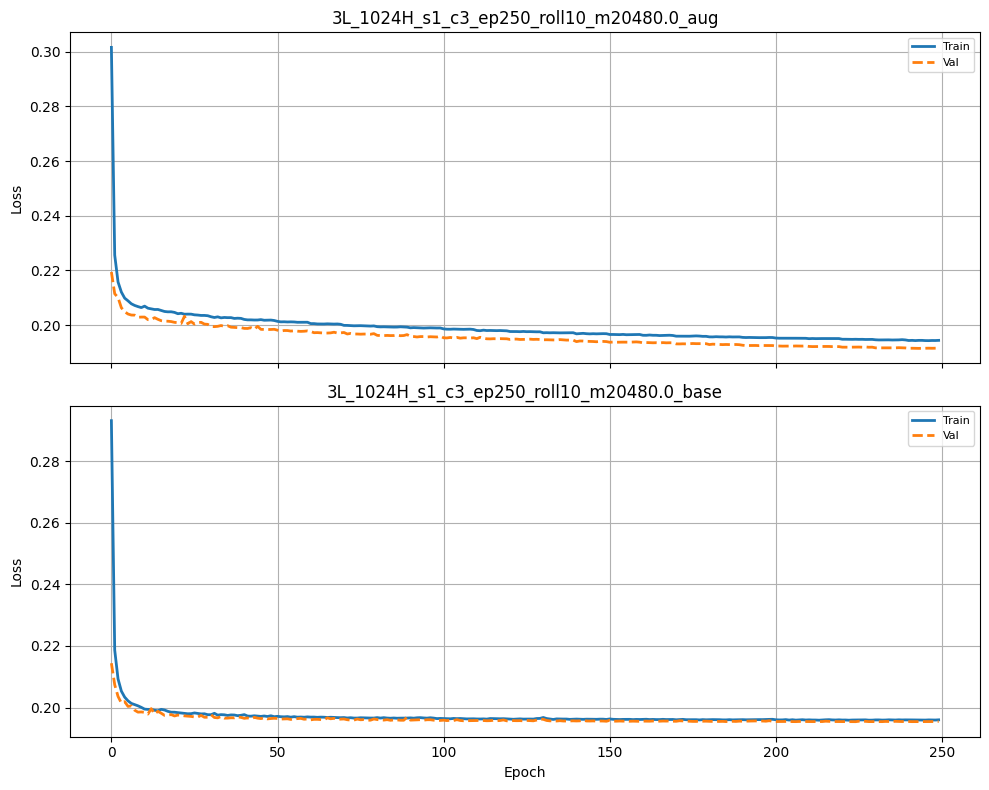

In [15]:
import matplotlib.pyplot as plt

num_conditions = len(results)

fig, axes = plt.subplots(
    nrows=num_conditions,
    ncols=1,
    figsize=(10, 4 * num_conditions),
    sharex=True
)

# 조건이 1개일 때 axes가 list가 아니라 단일 객체가 되는 것 방지
if num_conditions == 1:
    axes = [axes]

for ax, (setting_name, result) in zip(axes, results.items()):
    ax.plot(result['train_loss'], label="Train", linewidth=2)
    ax.plot(result['val_loss'], linestyle='--', label="Val", linewidth=2)

    ax.set_title(setting_name)
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()
